Original dimensions: 590 x 500

3x3 Translation Matrix:
[[  1.   0. 150.]
 [  0.   1.  80.]
 [  0.   0.   1.]]

New dimensions: 740 x 580

Saved: task4_translated_map.jpg


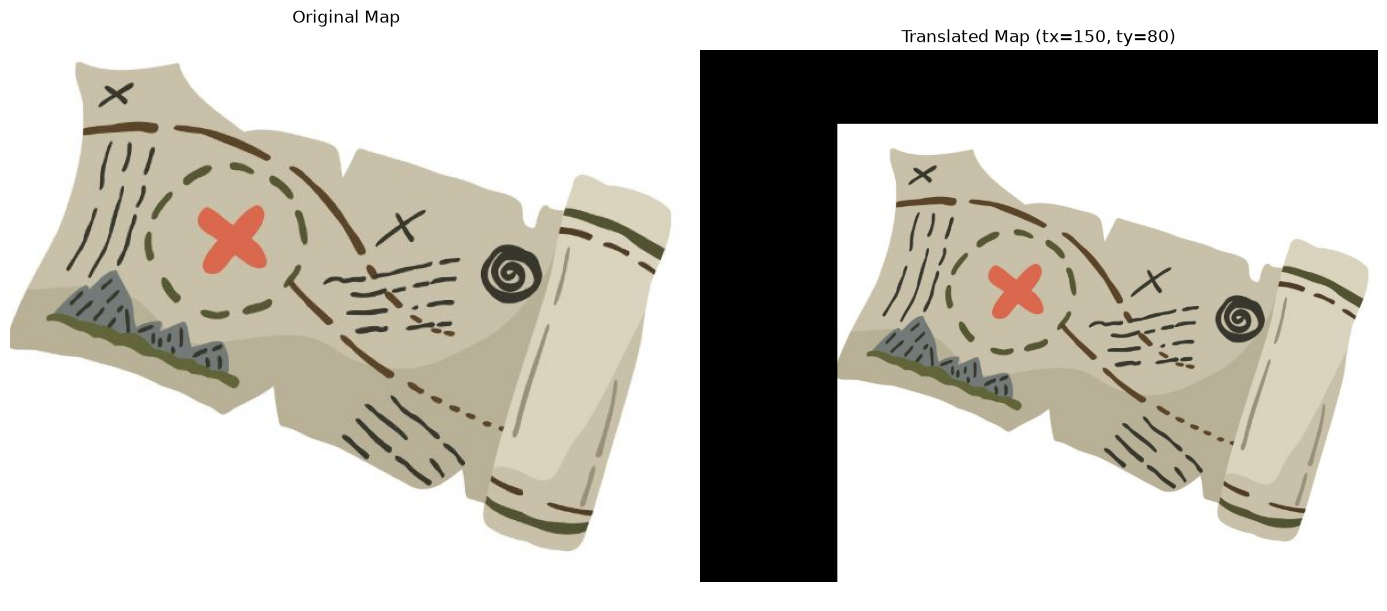

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Input and output files
# ---------------------------------------------------------
image_path = "map.jpg"
output_path = "task4_translated_map.jpg"

# ---------------------------------------------------------
# Read image
# ---------------------------------------------------------
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError(f"Could not find image: {image_path}")

h, w = img.shape[:2]

print("Original dimensions:", w, "x", h)

# ---------------------------------------------------------
# Translation values
# ---------------------------------------------------------
tx = 150
ty = 80

# ---------------------------------------------------------
# Required 3x3 translation matrix
#
# T = [ 1  0  tx ]
#     [ 0  1  ty ]
#     [ 0  0   1 ]
# ---------------------------------------------------------
T = np.array([
    [1.0, 0.0, tx],
    [0.0, 1.0, ty],
    [0.0, 0.0, 1.0]
], dtype=np.float32)

print("\n3x3 Translation Matrix:")
print(T)

# ---------------------------------------------------------
# New canvas size
# ---------------------------------------------------------
new_w = w + tx
new_h = h + ty

print("\nNew dimensions:", new_w, "x", new_h)

# ---------------------------------------------------------
# Apply translation
# ---------------------------------------------------------
result = cv2.warpPerspective(
    img,
    T,
    (new_w, new_h)
)

# ---------------------------------------------------------
# Save translated image
# ---------------------------------------------------------
cv2.imwrite(output_path, result)

print("\nSaved:", output_path)

# ---------------------------------------------------------
# Convert BGR to RGB for Matplotlib
# ---------------------------------------------------------
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# ---------------------------------------------------------
# Display original and translated image in Jupyter
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Map")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_rgb)
plt.title(f"Translated Map (tx={tx}, ty={ty})")
plt.axis("off")

plt.tight_layout()
plt.show()
